# EDA - Lily

In [1]:
#imports

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import librosa.display
import os
import librosa as lb
import soundfile as sf

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

# Demographics exploration

Demographic data - load and dataframe

  - Patient number
  - Age
  - Sex
  - Adult BMI (kg/m2)
  - Child Weight (kg)
  - Child Height (cm)


In [2]:
demographic_data = pd.read_csv('/Users/lilyeastwood/code/mi-mi-mia/smart-stethoscope/raw_data/demographic_info.txt',
                               sep=' ',
                               header=None,
                               names=["pid", "age", "sex", "adult_bmi", "child_weight", "child_height"])

print(demographic_data)

     pid    age  sex  adult_bmi  child_weight  child_height
0    101   3.00    F        NaN          19.0          99.0
1    102   0.75    F        NaN           9.8          73.0
2    103  70.00    F      33.00           NaN           NaN
3    104  70.00    F      28.47           NaN           NaN
4    105   7.00    F        NaN          32.0         135.0
..   ...    ...  ...        ...           ...           ...
121  222  60.00    M        NaN           NaN           NaN
122  223    NaN  NaN        NaN           NaN           NaN
123  224  10.00    F        NaN          32.3         143.0
124  225   0.83    M        NaN           7.8          74.0
125  226   4.00    M        NaN          16.7         103.0

[126 rows x 6 columns]


In [3]:
# Shape
print(f"Shape: {demographic_data.shape}")

# Column types
print("\nData types:")
print(demographic_data.dtypes)

# Null counts
print("\nNull counts:")
print(demographic_data.isnull().sum())

# Null percentages
print("\nNull percentages:")
print((demographic_data.isnull().sum() / len(demographic_data) * 100).round(2))

# Basic stats
print("\nDescriptive statistics:")
demographic_data.describe()

Shape: (126, 6)

Data types:
pid               int64
age             float64
sex              object
adult_bmi       float64
child_weight    float64
child_height    float64
dtype: object

Null counts:
pid              0
age              1
sex              1
adult_bmi       51
child_weight    82
child_height    84
dtype: int64

Null percentages:
pid              0.00
age              0.79
sex              0.79
adult_bmi       40.48
child_weight    65.08
child_height    66.67
dtype: float64

Descriptive statistics:


,pid,age,adult_bmi,child_weight,child_height
count,126.000000,125.00000,75.000000,44.000000,42.000000
mean,163.500000,42.99264,27.190000,21.361136,104.652381
std,36.517119,32.20907,5.372519,17.150885,30.793128
min,101.000000,0.25000,16.500000,7.140000,64.000000
25%,132.250000,4.00000,24.150000,11.755000,81.250000
50%,163.500000,60.00000,27.400000,15.100000,99.500000
75%,194.750000,71.00000,29.185000,24.325000,117.750000
max,226.000000,93.00000,53.500000,80.000000,183.000000


# Patient data exploration

Patient data - load and dataframe

  - Patient number
  - Disease


Patient data - load and dataframe

In [4]:
patient_data=pd.read_csv('/Users/lilyeastwood/code/mi-mi-mia/smart-stethoscope/raw_data/Respiratory_Sound_Database/Respiratory_Sound_Database/patient_diagnosis.csv',
                         names=['pid','disease'])
patient_data.head()

,pid,disease
0,101,URTI
1,102,Healthy
2,103,Asthma
3,104,COPD
4,105,URTI


In [5]:
patient_data.describe()

,pid
count,126.000000
mean,163.500000
std,36.517119
min,101.000000
25%,132.250000
50%,163.500000
75%,194.750000
max,226.000000


In [6]:
# Shape
print(f"Shape: {patient_data.shape}")

# Column types
print("\nData types:")
print(patient_data.dtypes)

# Null counts
print("\nNull counts:")
print(patient_data.isnull().sum())

# Null percentages
print("\nNull percentages:")
print((patient_data.isnull().sum() / len(patient_data) * 100).round(2))

# Basic stats
print("\nDescriptive statistics:")
patient_data.describe()

Shape: (126, 2)

Data types:
pid         int64
disease    object
dtype: object

Null counts:
pid        0
disease    0
dtype: int64

Null percentages:
pid        0.0
disease    0.0
dtype: float64

Descriptive statistics:


,pid
count,126.000000
mean,163.500000
std,36.517119
min,101.000000
25%,132.250000
50%,163.500000
75%,194.750000
max,226.000000


# Audio text file data exploration

Load and dataframes
  - Example txt file for an audio file
  - Audio txt files into one dataframe


Example of txt files of audio files

In [7]:
df=pd.read_csv('/Users/lilyeastwood/code/mi-mi-mia/smart-stethoscope/raw_data/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/160_1b3_Al_mc_AKGC417L.txt',sep='\t')
df.head()

,1.862,5.718,0,1
0,5.718,9.725,1,1
1,9.725,13.614,0,1
2,13.614,17.671,0,1
3,17.671,19.541,0,0


Load txt files into dataframe

In [8]:
path='/Users/lilyeastwood/code/mi-mi-mia/smart-stethoscope/raw_data/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/'
files=[s.split('.')[0] for s in os.listdir(path) if '.txt' in s]
files[:5]

print(f'Number of audio files: {len(files)}')

Number of audio files: 920


In [9]:
#build df of info - row per breath cycle

def getFilenameInfo(file):
    parts = file.split('_')
    return {
        'patient_number': parts[0],
        'recording_index': parts[1],
        'chest_location': parts[2],
        'acquisition_mode': parts[3],
        'equipment': parts[4]
    }

files_data=[]
for file in files:
    data=pd.read_csv(path + file + '.txt',sep='\t',names=['start','end','crackles','weezels'])
    name_data=getFilenameInfo(file)
    data['pid']=name_data['patient_number']
    data['recording_index']=name_data['recording_index']
    data['chest_location']=name_data['chest_location']
    data['acquisition_mode']=name_data['acquisition_mode']
    data['equipment']=name_data['equipment']
    data['filename']=file
    files_data.append(data)

files_df=pd.concat(files_data)
files_df.reset_index()
files_df.head()

,start,end,crackles,weezels,pid,recording_index,chest_location,acquisition_mode,equipment,filename
0,0.022,0.364,0,0,148,1b1,Al,sc,Meditron,148_1b1_Al_sc_Meditron
1,0.364,2.436,0,0,148,1b1,Al,sc,Meditron,148_1b1_Al_sc_Meditron
2,2.436,4.636,0,0,148,1b1,Al,sc,Meditron,148_1b1_Al_sc_Meditron
3,4.636,6.793,0,0,148,1b1,Al,sc,Meditron,148_1b1_Al_sc_Meditron
4,6.793,8.750,0,0,148,1b1,Al,sc,Meditron,148_1b1_Al_sc_Meditron


In [10]:
#join patient info with text files

patient_data.pid=patient_data.pid.astype('int32')
files_df.pid=files_df.pid.astype('int32')

audio_data=pd.merge(files_df,patient_data,on='pid')
audio_data.head()

,start,end,crackles,weezels,pid,recording_index,chest_location,acquisition_mode,equipment,filename,disease
0,0.022,0.364,0,0,148,1b1,Al,sc,Meditron,148_1b1_Al_sc_Meditron,URTI
1,0.364,2.436,0,0,148,1b1,Al,sc,Meditron,148_1b1_Al_sc_Meditron,URTI
2,2.436,4.636,0,0,148,1b1,Al,sc,Meditron,148_1b1_Al_sc_Meditron,URTI
3,4.636,6.793,0,0,148,1b1,Al,sc,Meditron,148_1b1_Al_sc_Meditron,URTI
4,6.793,8.750,0,0,148,1b1,Al,sc,Meditron,148_1b1_Al_sc_Meditron,URTI


In [11]:
#os.makedirs('csv_data')
data.to_csv('csv_data/data.csv',index=False)

# Audio file data exploration

Load and dataframes
  - start and end of audio files

In [12]:
#start and end of audiofiles - define parts of file that contain respiratory cycles

def getPureSample(raw_data,start,end,sr=22050):
    '''
    Takes a numpy array and spilts its using start and end args

    raw_data=numpy array of audio sample
    start=time
    end=time
    sr=sampling_rate
    mode=mono/stereo

    '''
    max_ind = len(raw_data)
    start_ind = min(int(start * sr), max_ind)
    end_ind = min(int(end * sr), max_ind)
    return raw_data[start_ind: end_ind]

<Axes: xlabel='None', ylabel='pid'>

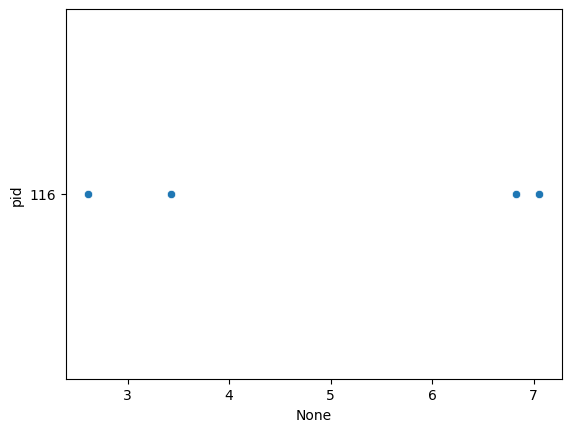

In [13]:
sns.scatterplot(x=(data.end-data.start), y=data.pid)

<Axes: ylabel='None'>

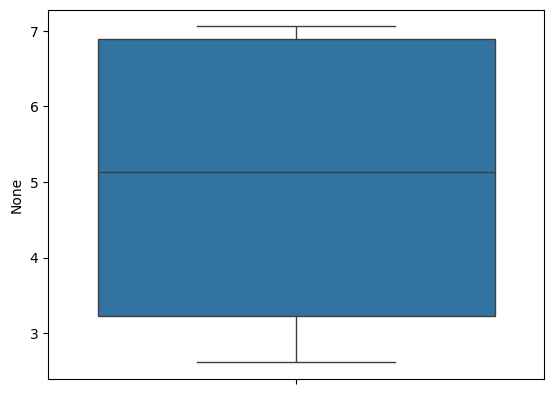

In [14]:
sns.boxplot(y=(data.end-data.start))

In [15]:
#iterate over dataset

for index,row in data.iterrows():
    print("Index ->",index)
    print("Data->\n",row)
    break

Index -> 0
Data->
 start                                0.022
end                                   3.45
crackles                                 0
weezels                                  0
pid                                    116
recording_index                        1b2
chest_location                          Pl
acquisition_mode                        sc
equipment                         Meditron
filename            116_1b2_Pl_sc_Meditron
Name: 0, dtype: object


In [16]:
## example from kaggle notebook
i,c=0,0
for index,row in data.iterrows():
    maxLen=6
    start=row['start']
    end=row['end']
    filename=row['filename']

    #If len > maxLen , change it to maxLen
    if end-start>maxLen:
        end=start+maxLen

    audio_file_loc=path + filename + '.wav'

    if index > 0:
        #check if more cycles exits for same patient if so then add i to change filename
        if data.iloc[index-1]['filename']==filename:
            i+=1
        else:
            i=0
    filename= filename + '_' + str(i) + '.wav'

    save_path='processed_audio_files/' + filename
    c+=1

    audioArr,sampleRate=lb.load(audio_file_loc)
    pureSample=getPureSample(audioArr,start,end,sampleRate)

    #pad audio if pureSample len < max_len
    reqLen=6*sampleRate
    padded_data = lb.util.pad_center(pureSample, size=reqLen)

    sf.write(file=save_path,data=padded_data,samplerate=sampleRate)
print('Total Files Processed: ',c)

Total Files Processed:  4


# All factors dataframe


In [17]:
print(f'Shape of Audio Data: {audio_data.shape}')
print(f'Shape of Patient Data: {patient_data.shape}')
print(f'Shape of Demographic Data: {demographic_data.shape}')


Shape of Audio Data: (6898, 11)
Shape of Patient Data: (126, 2)
Shape of Demographic Data: (126, 6)


In [18]:
allfactors_data=pd.merge(audio_data,demographic_data,on='pid')
allfactors_data
allfactors_data.head()
allfactors_data['disease'].value_counts()

disease
COPD              5746
Healthy            322
Pneumonia          285
URTI               243
Bronchiolitis      160
Bronchiectasis     104
LRTI                32
Asthma               6
Name: count, dtype: int64

In [19]:
# Shape
print(f"Shape: {allfactors_data.shape}")

# Column types
print("\nData types:")
print(allfactors_data.dtypes)

# Null counts
print("\nNull counts:")
print(allfactors_data.isnull().sum())

# Null percentages
print("\nNull percentages:")
print((allfactors_data.isnull().sum() / len(patient_data) * 100).round(2))

# Basic stats
print("\nDescriptive statistics:")
allfactors_data.describe()

Shape: (6898, 16)

Data types:
start               float64
end                 float64
crackles              int64
weezels               int64
pid                   int32
recording_index      object
chest_location       object
acquisition_mode     object
equipment            object
filename             object
disease              object
age                 float64
sex                  object
adult_bmi           float64
child_weight        float64
child_height        float64
dtype: object

Null counts:
start                  0
end                    0
crackles               0
weezels                0
pid                    0
recording_index        0
chest_location         0
acquisition_mode       0
equipment              0
filename               0
disease                0
age                   61
sex                   61
adult_bmi            894
child_weight        6149
child_height        6172
dtype: int64

Null percentages:
start                  0.00
end                    0.00
crack

,start,end,crackles,weezels,pid,age,adult_bmi,child_weight,child_height
count,6898.000000,6898.000000,6898.000000,6898.000000,6898.000000,6837.000000,6004.000000,749.000000,726.000000
mean,10.680312,13.380821,0.343578,0.201798,163.159322,61.955494,26.276126,16.921736,95.233058
std,9.871169,10.032744,0.474937,0.401371,33.434777,22.873476,5.700560,12.261544,24.521615
min,0.000000,0.250000,0.000000,0.000000,101.000000,0.250000,16.500000,7.140000,64.000000
25%,4.042000,6.820250,0.000000,0.000000,134.000000,58.000000,22.860000,11.000000,76.000000
50%,9.336000,12.125000,0.000000,0.000000,160.000000,68.000000,27.400000,13.000000,94.000000
75%,14.826250,17.671000,1.000000,0.000000,193.000000,75.000000,29.410000,16.700000,103.000000
max,84.365000,86.200000,1.000000,1.000000,226.000000,93.000000,53.500000,80.000000,183.000000


In [ ]:
#dealing with numericals

#one hot encode disease, equipment, acquisition mode, chest location, recording_index

cols = ['disease', 'recording_index', 'chest_location', 'acquisition_mode']
encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(allfactors_data[cols])

encoded_df = pd.DataFrame(encoded,
                          columns=encoder.get_feature_names_out(cols),
                          index=allfactors_data.index)

allfactors_data = pd.concat([allfactors_data, encoded_df], axis=1).drop(columns=cols)

#binary code gender
le = LabelEncoder()
allfactors_data['sex'] = allfactors_data['sex'].map({'M': 0, 'F': 1})
allfactors_data.head()


,start,end,crackles,weezels,pid,equipment,filename,age,sex,adult_bmi,...,recording_index_8p3,chest_location_Al,chest_location_Ar,chest_location_Ll,chest_location_Lr,chest_location_Pl,chest_location_Pr,chest_location_Tc,acquisition_mode_mc,acquisition_mode_sc
0,0.022,0.364,0,0,148,Meditron,148_1b1_Al_sc_Meditron,4.0,0.0,NaN,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.364,2.436,0,0,148,Meditron,148_1b1_Al_sc_Meditron,4.0,0.0,NaN,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2.436,4.636,0,0,148,Meditron,148_1b1_Al_sc_Meditron,4.0,0.0,NaN,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,4.636,6.793,0,0,148,Meditron,148_1b1_Al_sc_Meditron,4.0,0.0,NaN,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,6.793,8.750,0,0,148,Meditron,148_1b1_Al_sc_Meditron,4.0,0.0,NaN,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
#one BMI column
# find the age where adult_bmi starts being filled in vs child measurements
print(allfactors_data[allfactors_data['adult_bmi'].notna()]['age'].describe())
print(allfactors_data[allfactors_data['child_weight'].notna()]['age'].describe())

#raw BMI - old
# def calculate_bmi(row):
# if pd.notna(row['adult_bmi']):
# return row['adult_bmi']
# elif pd.notna(row['child_weight']) and pd.notna(row['child_height']):
# height_m = row['child_height'] / 100  # cm to metres
# return row['child_weight'] / (height_m ** 2)
# else:
# return np.nan

"""Linus code full elifs - old
def bmi_percentage(df): #input should be the dataframe?, output a new column with combined bmi percentage
    if df.age < 2:
            df.bmi_perc = (df.child_weight/(df.child_height/100)**2)/16.5
        elif df.gender == 'M':
            if df.age < 9: #ideally a finer mesh
                df.bmi_perc = (df.child_weight/(df.child_height/100)**2)/16
            elif df.age <= 11:
                df.bmi_perc = (df.child_weight/(df.child_height/100)**2)/17
            elif df.age <= 12:
                df.bmi_perc = (df.child_weight/(df.child_height/100)**2)/18
            elif df.age <= 13:
                df.bmi_perc = (df.child_weight/(df.child_height/100)**2)/18.6
            elif df.age <= 14:
                df.bmi_perc = (df.child_weight/(df.child_height/100)**2)/19.3
            elif df.age <= 15:
                df.bmi_perc = (df.child_weight/(df.child_height/100)**2)/20
            elif df.age <= 16:
                df.bmi_perc = (df.child_weight/(df.child_height/100)**2)/20.6
            elif df.age <= 17:
                df.bmi_perc = (df.child_weight/(df.child_height/100)**2)/21.3
            elif df.age <= 18:
                df.bmi_perc = (df.child_weight/(df.child_height/100)**2)/22
            elif df.age <= 19:
                df.bmi_perc = (df.child_weight/(df.child_height/100)**2)/22.6
            elif df.age <= 20:
                df.bmi_perc = (df.child_weight/(df.child_height/100)**2)/23
            else:
                df.bmi_perc = df.adult_bmi/25

        elif df.gender == 'F':
            if df.age < 9: #ideally a finer mesh
                df.bmi_perc = (df.child_weight/(df.child_height/100)**2)/16
            elif df.age <= 11:
                df.bmi_perc = (df.child_weight/(df.child_height/100)**2)/17.5
            elif df.age <= 12:
                df.bmi_perc = (df.child_weight/(df.child_height/100)**2)/18
            elif df.age <= 13:
                df.bmi_perc = (df.child_weight/(df.child_height/100)**2)/18.6
            elif df.age <= 14:
                df.bmi_perc = (df.child_weight/(df.child_height/100)**2)/19.3
            elif df.age <= 15:
                df.bmi_perc = (df.child_weight/(df.child_height/100)**2)/20
            elif df.age <= 16:
                df.bmi_perc = (df.child_weight/(df.child_height/100)**2)/20.5
            elif df.age <= 17:
                df.bmi_perc = (df.child_weight/(df.child_height/100)**2)/20.8
            elif df.age <= 18:
                df.bmi_perc = (df.child_weight/(df.child_height/100)**2)/21.2
            elif df.age <= 19:
                df.bmi_perc = (df.child_weight/(df.child_height/100)**2)/21.5
            elif df.age <= 20:
                df.bmi_perc = (df.child_weight/(df.child_height/100)**2)/21.8
            else:
                df.bmi_perc = df.adult_bmi/25

        return df.bmi_perc

demographic_data['bmi_percentage'] = demographic_data.apply(bmi_percentage, axis=1)
demographic_data.head()

allfactors_data['bmi'] = allfactors_data.apply(calculate_bmi, axis=1)

# check
print(allfactors_data['bmi'].isnull().sum())  # should be just the few edge cases
allfactors_data[['adult_bmi', 'child_weight', 'child_height', 'bmi']].head(10)

allfactors_data.head()"""

def calculate_bmi(row):
    if row['age'] >= 19:  # adult
        return row['adult_bmi'] / 25 if pd.notna(row['adult_bmi']) else np.nan

    if pd.isna(row['child_weight']) or pd.isna(row['child_height']):
        return np.nan

    raw_bmi = row['child_weight'] / (row['child_height'] / 100) ** 2
    age = row['age']
    sex = row['sex']  # M=0, F=1

    if age < 2:
        return raw_bmi / 16.5
    elif sex == 0:  # Male
        thresholds = [(9, 16), (11, 17), (12, 18), (13, 18.6), (14, 19.3),
                      (15, 20), (16, 20.6), (17, 21.3), (18, 22), (19, 22.6), (20, 23)]
        for max_age, divisor in thresholds:
            if age <= max_age:
                return raw_bmi / divisor
    elif sex == 1:  # Female
        thresholds = [(9, 16), (11, 17.5), (12, 18), (13, 18.6), (14, 19.3),
                      (15, 20), (16, 20.5), (17, 20.8), (18, 21.2), (19, 21.5), (20, 21.8)]
        for max_age, divisor in thresholds:
            if age <= max_age:
                return raw_bmi / divisor

    return np.nan

allfactors_data['bmi'] = allfactors_data.apply(calculate_bmi, axis=1)

print(allfactors_data['bmi'].isnull().sum())
allfactors_data['bmi'].describe()

#length of breathing cycle
allfactors_data['cycle_length'] = allfactors_data['end']-allfactors_data['start']

#flip healthy column
allfactors_data['disease_Healthy'] = 1 - allfactors_data['disease_Healthy']
allfactors_data = allfactors_data.rename(columns={'disease_Healthy': 'disease_not_healthy'})

count    6004.000000
mean       69.645070
std         9.268683
min        19.000000
25%        63.000000
50%        70.000000
75%        75.000000
max        93.000000
Name: age, dtype: float64
count    749.000000
mean       3.114433
std        3.266013
min        0.250000
25%        0.830000
50%        2.000000
75%        4.000000
max       16.000000
Name: age, dtype: float64
168


In [29]:
allfactors_data.head()

print(allfactors_data.dtypes)

start                  float64
end                    float64
crackles                 int64
weezels                  int64
pid                      int32
                        ...   
chest_location_Tc      float64
acquisition_mode_mc    float64
acquisition_mode_sc    float64
bmi                    float64
cycle_length           float64
Length: 65, dtype: object


<Axes: >

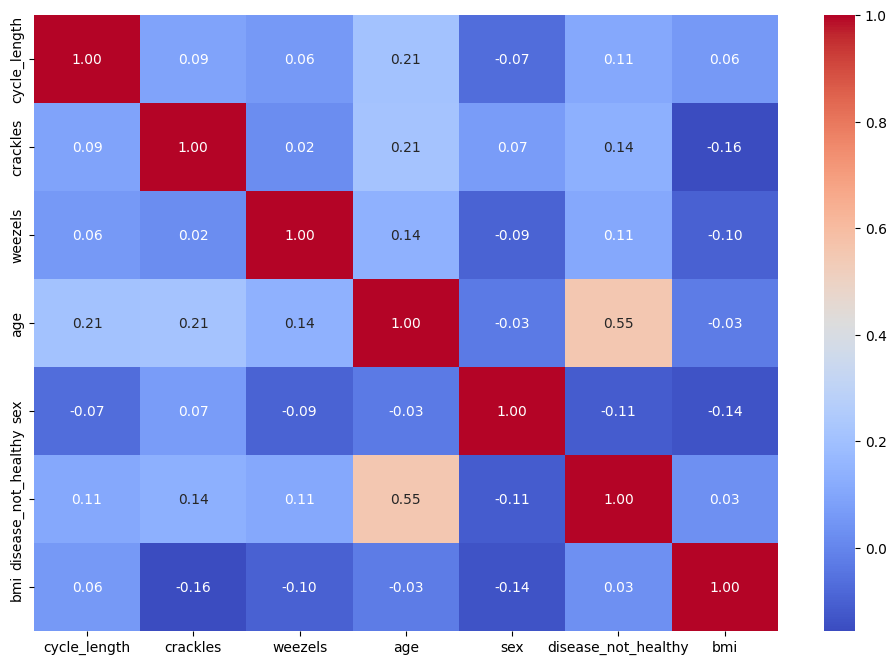

In [ ]:
cols = ['cycle_length', 'crackles', 'weezels', 'age', 'sex', 'disease_not_healthy', 'bmi']

plt.figure(figsize=(12, 8))
sns.heatmap(allfactors_data[cols].corr(),
            annot=True,
            fmt='.2f',
            cmap='coolwarm')